In [2]:
# Import a few libraries that may be useful for this project
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import bambi as bmb
import arviz as az
import glob
import os
from pathlib import  Path
import fnmatch
#import cmocean as cmo
# set seed at the beginning for reproducibility
seed=42
np.random.seed(seed)

In [3]:
# load the tea data
tea_df=pd.read_excel('processed/OSL_Demonstration_Data_Collection_in_Tea_Plantation.xlsx', sheet_name='data')
# add the yield per heactare column
tea_df['yield_kg_ha'] = tea_df['yield_kg'] / tea_df['area_ha']
tea_df.head()

,date,Farm,treatment,area_ha,yield_kg,replicate,yield_kg_ha
0,2025-12-15,Bigutu,OSL27-250,3.0000,496.00,NaN,165.333333
1,2025-12-15,Bigutu,control,1.5000,198.00,NaN,132.000000
2,2025-12-18,RAB,NPK50-OSL31-250,0.0025,1.02,1.0,408.000000
3,2025-12-18,RAB,NPK70-OSL31-250,0.0025,0.87,1.0,348.000000
4,2025-12-18,RAB,NPK80-OSL31-250,0.0025,0.80,1.0,320.000000


In [97]:
# check data info
tea_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         311 non-null    datetime64[ns]
 1   Farm         311 non-null    object        
 2   treatment    311 non-null    object        
 3   area_ha      311 non-null    float64       
 4   yield_kg     311 non-null    float64       
 5   replicate    261 non-null    float64       
 6   yield_kg_ha  311 non-null    float64       
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 17.1+ KB


It looks like the date colum is the date time.
Now we will calculate the day of the year from the date column

In [4]:
# get the day of the year from date colum
# Example transformation
tea_df['days_elapsed'] = (tea_df.groupby(['Farm'])['date'].transform(lambda x: x - x.min()).dt.days)

# check the data after transformation
tea_df.head()

,date,Farm,treatment,area_ha,yield_kg,replicate,yield_kg_ha,days_elapsed
0,2025-12-15,Bigutu,OSL27-250,3.0000,496.00,NaN,165.333333,0
1,2025-12-15,Bigutu,control,1.5000,198.00,NaN,132.000000,0
2,2025-12-18,RAB,NPK50-OSL31-250,0.0025,1.02,1.0,408.000000,0
3,2025-12-18,RAB,NPK70-OSL31-250,0.0025,0.87,1.0,348.000000,0
4,2025-12-18,RAB,NPK80-OSL31-250,0.0025,0.80,1.0,320.000000,0


In [6]:
# get the fertilizer reduction experiment data
rab_data=tea_df.query('Farm=="RAB"')
gtc_data=tea_df.query('Farm!="RAB"')
rab_data.head()

,date,Farm,treatment,area_ha,yield_kg,replicate,yield_kg_ha,days_elapsed
2,2025-12-18,RAB,NPK50-OSL31-250,0.0025,1.02,1.0,408.0,0
3,2025-12-18,RAB,NPK70-OSL31-250,0.0025,0.87,1.0,348.0,0
4,2025-12-18,RAB,NPK80-OSL31-250,0.0025,0.80,1.0,320.0,0
5,2025-12-18,RAB,NPK100-OSL31-250,0.0025,0.93,1.0,372.0,0
6,2025-12-18,RAB,control,0.0025,1.03,1.0,412.0,0


In [102]:
#look at the header of the gtc data
# rename the treatment values for better readability

gtc_data.loc[:,'treatment'] = gtc_data['treatment'].replace({'OSL27-250': 'OSL-Treated', 'control': 'UTC'})

# save data for later use
gtc_data.to_csv('processed/gtc_data.csv', index=False)

gtc_data.head()

,date,Farm,treatment,area_ha,yield_kg,replicate,yield_kg_ha,days_elapsed
0,2025-12-15,Bigutu,OSL-Treated,3.0,496.0,NaN,165.333333,0
1,2025-12-15,Bigutu,UTC,1.5,198.0,NaN,132.000000,0
22,2025-12-23,Ntendezi,OSL-Treated,0.2,138.0,NaN,690.000000,0
23,2025-12-23,Ntendezi,UTC,0.2,64.9,NaN,324.500000,0
44,2025-12-30,Bigutu,OSL-Treated,3.0,361.0,NaN,120.333333,15


In [105]:
gtc_cum_yield=gtc_data.groupby(['days_elapsed','Farm', 'treatment'])['yield_kg_ha'].mean().reset_index()
gtc_cum_yield['cumulative_yield'] = gtc_cum_yield.groupby(['Farm', 'treatment'])['yield_kg_ha'].cumsum()

#look at the cumulative yield data
gtc_cum_yield.head()

,days_elapsed,Farm,treatment,yield_kg_ha,cumulative_yield
0,0,Bigutu,OSL-Treated,165.333333,165.333333
1,0,Bigutu,UTC,132.000000,132.000000
2,0,Ntendezi,OSL-Treated,690.000000,690.000000
3,0,Ntendezi,UTC,324.500000,324.500000
4,15,Bigutu,OSL-Treated,120.333333,285.666667


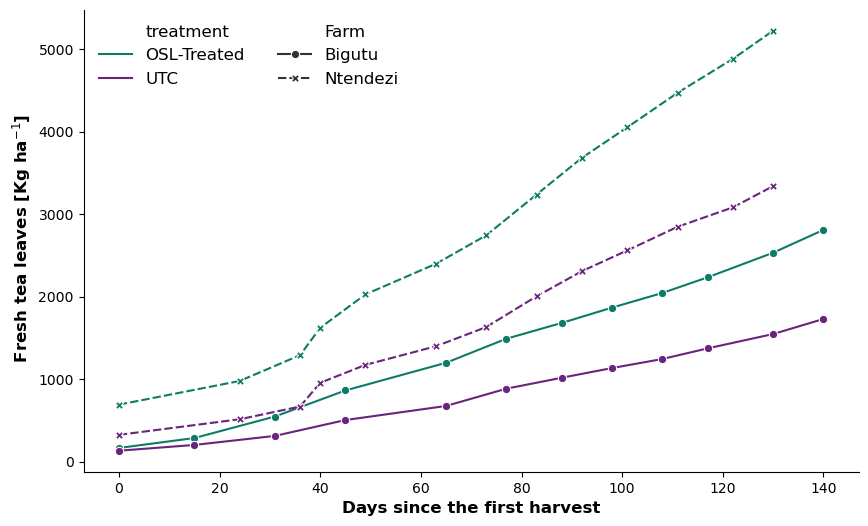

In [125]:
#plot the cummulative data for the two treatments
plt.figure(figsize=(10,6))

colors={"UTC":"#69247C", "OSL-Treated":"#0D7C66"}
ax=sns.lineplot(data=gtc_cum_yield, x="days_elapsed", y="cumulative_yield", hue="treatment", palette=colors,
                markers=True, style="Farm",err_kws={'linewidth': 1.5, 'alpha':1})
plt.ylabel(" Fresh tea leaves [Kg ha$^{-1}$]", color='black', size=12, weight='bold')
plt.xlabel("Days since the first harvest", color='black', size=12, weight='bold')
ax.legend(title=None, frameon=False, loc='upper left', ncol=2, fontsize=12)
# remove the upper and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#plt.savefig("results/figures/Bigutu_tea_cumulative_yield.png", dpi=600, bbox_inches='tight')
plt.show();

In [116]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Since you have 2 observations per farm/date combination (1 UTC, 1 treated),
# this fully fixed model will resolve your degrees of freedom issue.
fixed_model = smf.ols(
    "cumulative_yield ~ C(treatment) * C(Farm)* days_elapsed", 
    data=gtc_cum_yield
).fit()

print(fixed_model.summary())

                            OLS Regression Results                            
Dep. Variable:       cumulative_yield   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     584.8
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           1.00e-39
Time:                        17:19:51   Log-Likelihood:                -312.54
No. Observations:                  50   AIC:                             641.1
Df Residuals:                      42   BIC:                             656.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

In [117]:
import bambi as bmb

# (1|Farm) tells the model that each farm gets its own random baseline intercept
tier1_bambi_model = bmb.Model(
    "cumulative_yield ~ C(treatment) * C(Farm)* days_elapsed",
    data=gtc_cum_yield
)

# 2. Fit the model using MCMC sampling
# This will automatically use PyMC as the backend
tier1_bambi_results = tier1_bambi_model.fit(
    draws=4000,       # Number of samples to keep per chain
    tune=2000,        # Number of burn-in/tuning steps
    chains=4,         # Number of independent MCMC chains
    target_accept=0.95, # Bumped up slightly to handle complex interactions smoothly
    cores=8           # Use all available CPU cores for parallel sampling
)

c:\Users\Benjamin\anaconda3\envs\stats\Lib\site-packages\threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [cumulative_yield_sigma, Intercept, C(treatment), C(Farm), C(treatment):C(Farm), days_elapsed, C(treatment):days_elapsed, C(Farm):days_elapsed, C(treatment):C(Farm):days_elapsed]


Output()

Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 596 seconds.


In [118]:
# View a summary table of the fixed and random effects
summary_df = az.summary(tier1_bambi_results)
summary_df

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,19.246,81.713,-135.483,171.730,1.084,0.670,5688.0,9337.0,1.0
C(treatment)[UTC],-8.798,114.895,-228.051,204.909,1.587,0.968,5230.0,8348.0,1.0
C(Farm)[Ntendezi],170.971,115.834,-43.547,397.369,1.593,0.970,5289.0,8131.0,1.0
"C(treatment):C(Farm)[UTC, Ntendezi]",-214.718,162.978,-519.771,93.928,2.374,1.410,4714.0,7249.0,1.0
days_elapsed,19.123,0.931,17.325,20.847,0.012,0.008,5672.0,8531.0,1.0
C(treatment):days_elapsed[UTC],-7.495,1.306,-9.889,-4.975,0.018,0.011,5204.0,8078.0,1.0
C(Farm):days_elapsed[Ntendezi],18.552,1.382,15.988,21.282,0.019,0.012,5288.0,7728.0,1.0
"C(treatment):C(Farm):days_elapsed[UTC, Ntendezi]",-5.039,1.948,-8.701,-1.301,0.028,0.017,4866.0,7452.0,1.0
cumulative_yield_sigma,141.112,15.904,112.784,171.085,0.156,0.153,10818.0,10251.0,1.0


In [8]:
# look at the rab data
rab_data.head()

,date,Farm,treatment,area_ha,yield_kg,replicate,yield_kg_ha,days_elapsed
2,2025-12-18,RAB,NPK50-OSL31-250,0.0025,1.02,1.0,408.0,0
3,2025-12-18,RAB,NPK70-OSL31-250,0.0025,0.87,1.0,348.0,0
4,2025-12-18,RAB,NPK80-OSL31-250,0.0025,0.80,1.0,320.0,0
5,2025-12-18,RAB,NPK100-OSL31-250,0.0025,0.93,1.0,372.0,0
6,2025-12-18,RAB,control,0.0025,1.03,1.0,412.0,0


In [9]:
# calculate cumulative yield for the rab data
rab_cum_yield=rab_data.groupby(['days_elapsed', 'treatment','replicate'])['yield_kg_ha'].mean().reset_index()
rab_cum_yield['cumulative_yield'] = rab_cum_yield.groupby(['treatment','replicate'])['yield_kg_ha'].cumsum()
rab_cum_yield.head()

,days_elapsed,treatment,replicate,yield_kg_ha,cumulative_yield
0,0,NPK100-OSL31-250,1.0,372.0,372.0
1,0,NPK100-OSL31-250,2.0,452.0,452.0
2,0,NPK100-OSL31-250,3.0,496.0,496.0
3,0,NPK100-OSL31-250,4.0,332.0,332.0
4,0,NPK50-OSL31-250,1.0,408.0,408.0


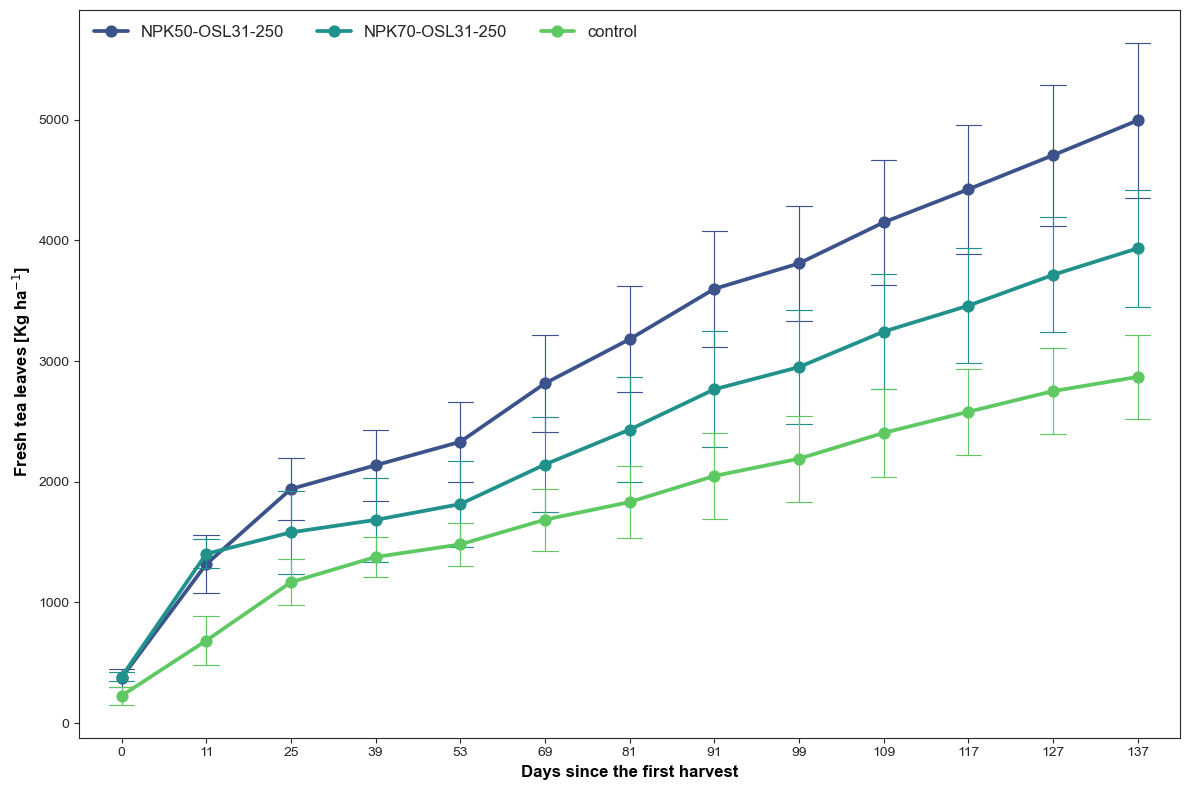

In [10]:
# plot lineplot for tea yield across treatments and over time
sns.set_style('ticks')
fig=plt.figure(figsize=[12, 8], tight_layout=True)
selected=["control", "NPK70-OSL31-250","NPK50-OSL31-250"]
sns.pointplot(data=rab_cum_yield[rab_cum_yield['treatment'].isin(selected)], x="days_elapsed",y="cumulative_yield", hue="treatment", palette='viridis', errorbar="se", capsize=0.3,err_kws={'linewidth': 0.83, 'alpha':1})
plt.ylabel(" Fresh tea leaves [Kg ha$^{-1}$]", color='black', size=12, weight='bold')
plt.xlabel("Days since the first harvest", color='black', size=12, weight='bold')
plt.legend(loc='upper left', frameon=False, title='', fontsize=12, ncol=3)
plt.savefig("results/figures/RAB_tea_results_lineplot.png", dpi=600, bbox_inches='tight') 
plt.show();

In [11]:
# subset of the data for the fixed effects model
rab_subset = rab_cum_yield[rab_cum_yield['treatment'].isin(selected)]
rab_subset.head()

,days_elapsed,treatment,replicate,yield_kg_ha,cumulative_yield
4,0,NPK50-OSL31-250,1.0,408.0,408.0
5,0,NPK50-OSL31-250,2.0,564.0,564.0
6,0,NPK50-OSL31-250,3.0,276.0,276.0
7,0,NPK50-OSL31-250,4.0,252.0,252.0
8,0,NPK70-OSL31-250,1.0,348.0,348.0


In [12]:
# looka at the impact of OSL and fertilizer reduction on the cumulative yield

import statsmodels.formula.api as smf

final_mixed_model = smf.mixedlm(
    "cumulative_yield ~ C(treatment) * days_elapsed",
    data=rab_subset,
    groups=rab_subset["replicate"] # The 4 replicates are the groups
)

final_mixed_results = final_mixed_model.fit()
final_mixed_results.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                             Mixed Linear Model Regression Results
===============================================================================================
Model:                       MixedLM            Dependent Variable:            cumulative_yield
No. Observations:            154                Method:                        REML            
No. Groups:                  4                  Scale:                         130729.4986     
Min. group size:             37                 Log-Likelihood:                -1112.2254      
Max. group size:             39                 Converged:                     Yes             
Mean group size:             38.5                                                              
-----------------------------------------------------------------------------------------------
                                               Coef.    Std.Err.   z    P>|z|  [0.025   0.975] 
-----------------------------------------------------------------------------------------------
Intercept                                       799.858  351.270  2.277 0.023  111.382 1488.334
C(treatment)[T.NPK70-OSL31-250]                -175.765  145.589 -1.207 0.227 -461.114  109.585
C(treatment)[T.control]                        -298.037  140.019 -2.129 0.033 -572.469  -23.605
days_elapsed                                     30.664    1.159 26.468 0.000   28.393   32.934
C(treatment)[T.NPK70-OSL31-250]:days_elapsed     -6.725    1.685 -3.991 0.000  -10.028   -3.422
C(treatment)[T.control]:days_elapsed            -13.153    1.638 -8.028 0.000  -16.364   -9.942
Group Var                                    454350.728 1043.548                               
===============================================================================================

"""

In [16]:
# select end points
rab_end_points = rab_subset.groupby(['treatment','replicate']).tail(1) 
rab_end_points

,days_elapsed,treatment,replicate,yield_kg_ha,cumulative_yield
242,137,NPK50-OSL31-250,1.0,400.0,6148.0
243,137,NPK50-OSL31-250,2.0,360.0,6008.0
244,137,NPK50-OSL31-250,3.0,276.0,4236.0
245,137,NPK50-OSL31-250,4.0,120.0,3584.0
246,137,NPK70-OSL31-250,1.0,284.0,4500.0
247,137,NPK70-OSL31-250,2.0,228.0,4708.0
248,137,NPK70-OSL31-250,3.0,156.0,3968.0
249,137,NPK70-OSL31-250,4.0,212.0,2560.0
254,137,control,1.0,120.0,3624.0
255,137,control,2.0,84.0,3308.0


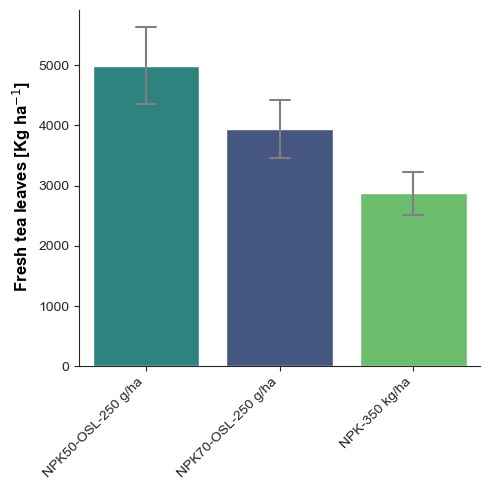

In [44]:
# plot barplot for tea yield across treatments and over time
sns.set_style('ticks')
fig=plt.figure(figsize=[5, 5], tight_layout=True)
rab_end_points.loc[:, 'treatment'] = rab_end_points['treatment'].replace({'control': 'NPK-350 kg/ha','NPK70-OSL31-250': 'NPK70-OSL-250 g/ha', 'NPK50-OSL31-250': 'NPK50-OSL-250 g/ha'})
orders = ['NPK70-OSL-250 g/ha','NPK50-OSL-250 g/ha', 'NPK-350 kg/ha']
ax=sns.barplot(data=rab_end_points, x="treatment", y="cumulative_yield", hue="treatment",palette="viridis", hue_order=orders,errorbar='se',err_kws={'color': 'gray','linewidth': 1.5}, capsize=.15)
plt.ylabel(" Fresh tea leaves [Kg ha$^{-1}$]", color='black', size=12, weight='bold')
plt.xlabel("")
# rotate x-axis labels
plt.xticks(rotation=45, ha="right")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig("results/figures/RAB_tea_results.png", dpi=600, bbox_inches='tight')
plt.show();

In [ ]:
# looka at the impact of OSL and fertilizer reduction on the cumulative yield

import statsmodels.formula.api as smf

final_mixed_model2 = smf.mixedlm(
    "cumulative_yield ~ 1 + C(treatment)",
    data=rab_end_points,
    groups=rab_end_points["replicate"] # The 4 replicates are the groups
)

final_mixed_results2 = final_mixed_model2.fit()
final_mixed_results2.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                       Mixed Linear Model Regression Results
====================================================================================
Model:                    MixedLM        Dependent Variable:        cumulative_yield
No. Observations:         12             Method:                    REML            
No. Groups:               4              Scale:                     190300.4159     
Min. group size:          3              Log-Likelihood:            -73.5257        
Max. group size:          3              Converged:                 Yes             
Mean group size:          3.0                                                       
------------------------------------------------------------------------------------
                                     Coef.    Std.Err.   z   P>|z|  [0.025   0.975] 
------------------------------------------------------------------------------------
Intercept                            2869.000  505.720 5.673 0.000 1877.808 3860.192
C(treatment)[T.NPK50-OSL-250 g/ha]   2125.000  308.464 6.889 0.000 1520.421 2729.579
C(treatment)[T.NPK70-OSL-250 g/ha]   1065.000  308.464 3.453 0.001  460.421 1669.579
Group Var                          832708.833 2054.259                              
====================================================================================

"""

In [27]:
fixed_model3 = smf.ols(
"cumulative_yield ~ C(treatment)",
    data=rab_end_points,
).fit() 

print(fixed_model3.summary())

                            OLS Regression Results                            
Dep. Variable:       cumulative_yield   R-squared:                       0.495
Model:                            OLS   Adj. R-squared:                  0.383
Method:                 Least Squares   F-statistic:                     4.414
Date:                Tue, 02 Jun 2026   Prob (F-statistic):             0.0461
Time:                        22:56:18   Log-Likelihood:                -98.331
No. Observations:                  12   AIC:                             202.7
Df Residuals:                       9   BIC:                             204.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte